# Importing various Libraries

In [298]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset

In [299]:
data = pd.read_csv("../Datasets/employee_churn.csv")


data

,avg_monthly_hrs,department,filed_complaint,last_evaluation,n_projects,recently_promoted,salary,satisfaction,status,tenure
0,221,engineering,NaN,0.932868,4,NaN,low,0.829896,Left,5.0
1,232,support,NaN,NaN,3,NaN,low,0.834544,Employed,2.0
2,184,sales,NaN,0.788830,3,NaN,medium,0.834988,Employed,3.0
3,206,sales,NaN,0.575688,4,NaN,low,0.424764,Employed,2.0
4,249,sales,NaN,0.845217,3,NaN,low,0.779043,Employed,3.0
...,...,...,...,...,...,...,...,...,...,...
14244,178,IT,NaN,0.735865,5,NaN,low,0.263282,Employed,5.0
14245,257,sales,NaN,0.638604,3,NaN,low,0.868209,Employed,2.0
14246,232,finance,1.0,0.847623,5,NaN,medium,0.898917,Left,5.0
14247,130,IT,NaN,0.757184,4,NaN,medium,0.641304,Employed,3.0


## Counting Missing Values

In [300]:

missing_counts = data.isnull().sum()
print(missing_counts[missing_counts > 0])  # Only print columns with missing values

department             709
filed_complaint      12191
last_evaluation       1532
recently_promoted    13949
satisfaction           181
tenure                 181
dtype: int64


## Visualizing Missing Values with Bar PLot

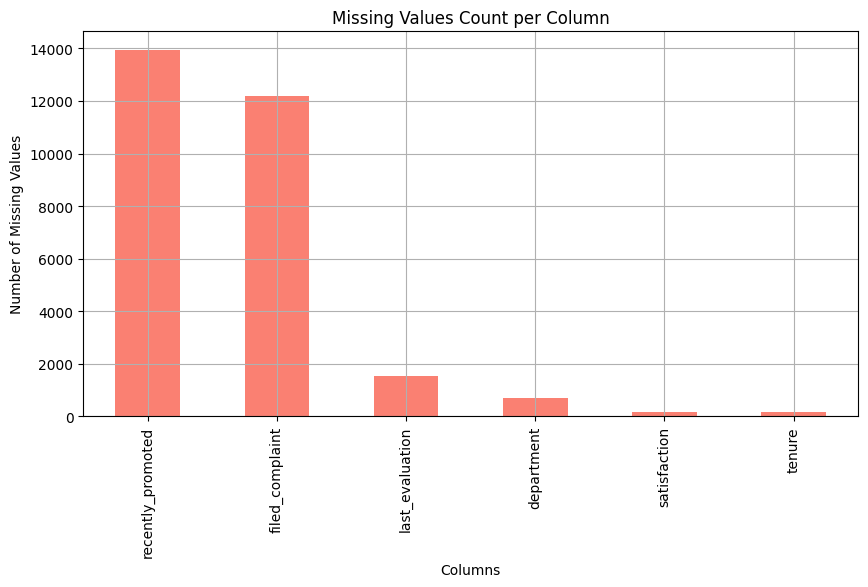

In [301]:
missing_counts = missing_counts[missing_counts > 0]
missing_counts.sort_values(ascending=False).plot(kind='bar', figsize=(10,5), color='salmon')
plt.title("Missing Values Count per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.grid(True)
plt.show()


# Visualizing Missing Values as  a Heatmap

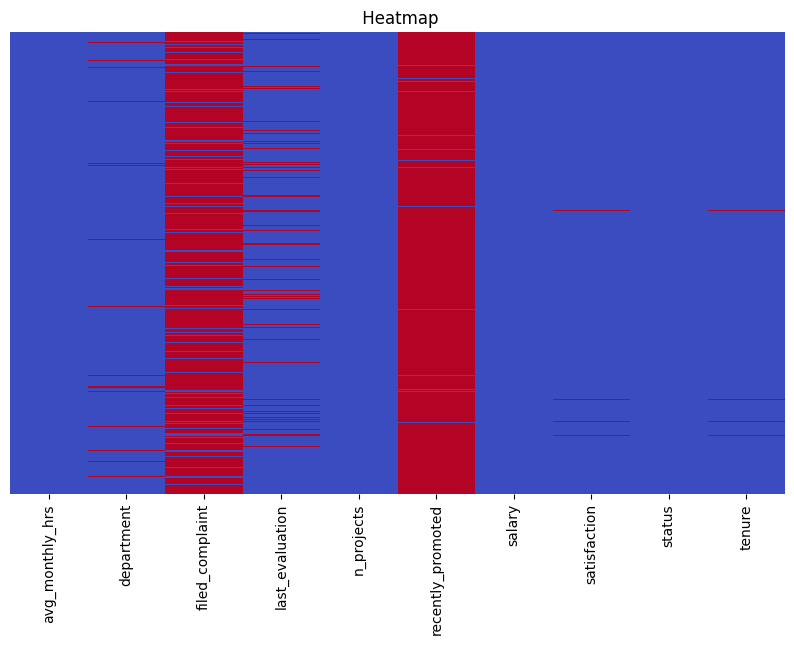

In [302]:
# plt.figure(figsize=(12,6))
# sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
# plt.title("Heatmap of Missing Values in Dataset")
# plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(data.isna(),cbar = False, cmap = 'coolwarm' , yticklabels = False)
plt.title(" Heatmap")
plt.show()

# Applying Label Encoder

In [303]:
encoder = LabelEncoder()

categorical_cols = ['salary' , 'department' , 'status']
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])


data.head()    

,avg_monthly_hrs,department,filed_complaint,last_evaluation,n_projects,recently_promoted,salary,satisfaction,status,tenure
0,221,2,NaN,0.932868,4,NaN,1,0.829896,1,5.0
1,232,10,NaN,NaN,3,NaN,1,0.834544,0,2.0
2,184,9,NaN,0.788830,3,NaN,2,0.834988,0,3.0
3,206,9,NaN,0.575688,4,NaN,1,0.424764,0,2.0
4,249,9,NaN,0.845217,3,NaN,1,0.779043,0,3.0


# Filling Nan Values

In [304]:
for column in ['department']:
    mode_value = data[column].mode()[0]
    data[column] = data[column].fillna(mode_value)


# Numerical columns ke liye median fill
data['last_evaluation'] = data['last_evaluation'].fillna(data['last_evaluation'].median())
data['satisfaction'] = data['satisfaction'].fillna(data['satisfaction'].median())
data['tenure'] = data['tenure'].fillna(data['tenure'].median())




# Again Counting Missing Values

In [305]:

missing_counts = data.isnull().sum()
print(missing_counts[missing_counts > 0])  # Only print columns with missing values

filed_complaint      12191
recently_promoted    13949
dtype: int64


# Visualizing on heat Map

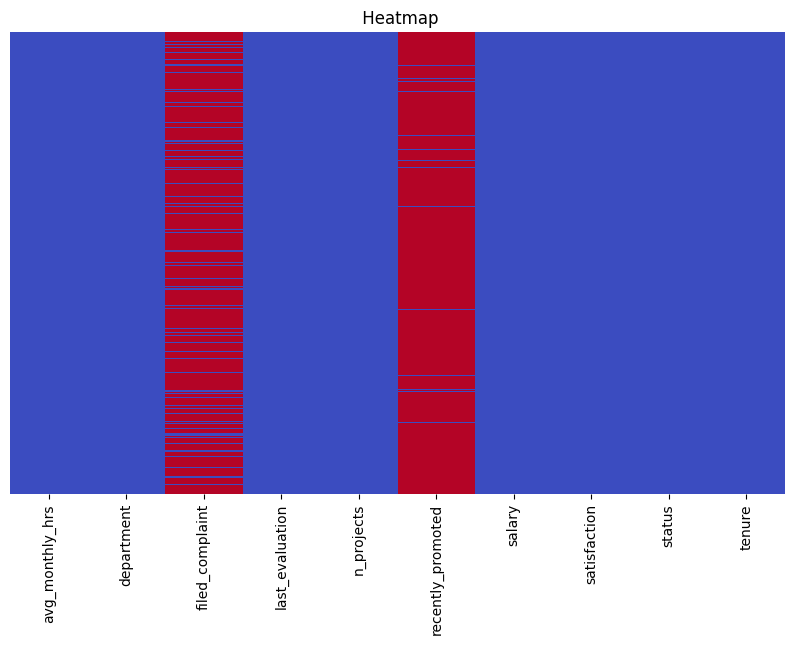

In [306]:
# plt.figure(figsize=(12,6))
# sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
# plt.title("Heatmap of Missing Values in Dataset")
# plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(data.isna(),cbar = False, cmap = 'coolwarm' , yticklabels = False)
plt.title(" Heatmap")
plt.show()

# Preparing X and Y

In [307]:
X = data.drop(columns = ['status','filed_complaint','recently_promoted'])
Y = data['status']

# Scaling the Features

In [308]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train/Test Split

In [309]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)


# Loading and Training the Model

In [310]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

# Predictions and Accuracy

In [311]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.7719298245614035


# Confusion Matrix

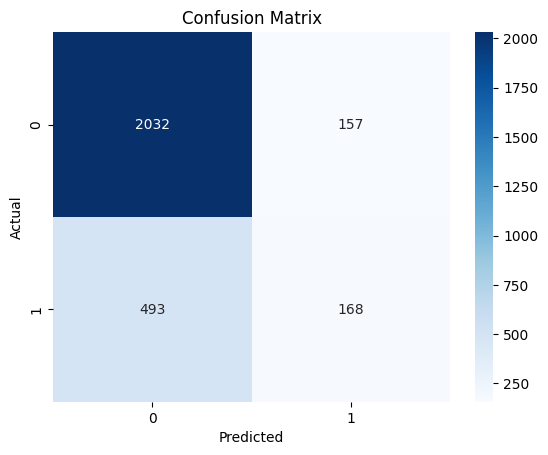

In [312]:

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Classification Report

In [313]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.93      0.86      2189
           1       0.52      0.25      0.34       661

    accuracy                           0.77      2850
   macro avg       0.66      0.59      0.60      2850
weighted avg       0.74      0.77      0.74      2850



# ROC Curve & AUC

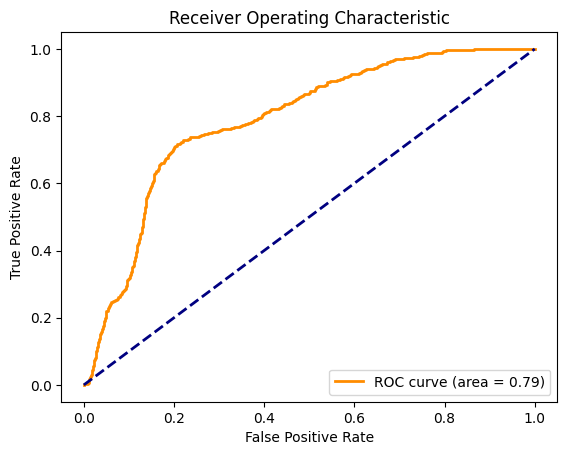

In [314]:
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


# Feature Impact Visualization

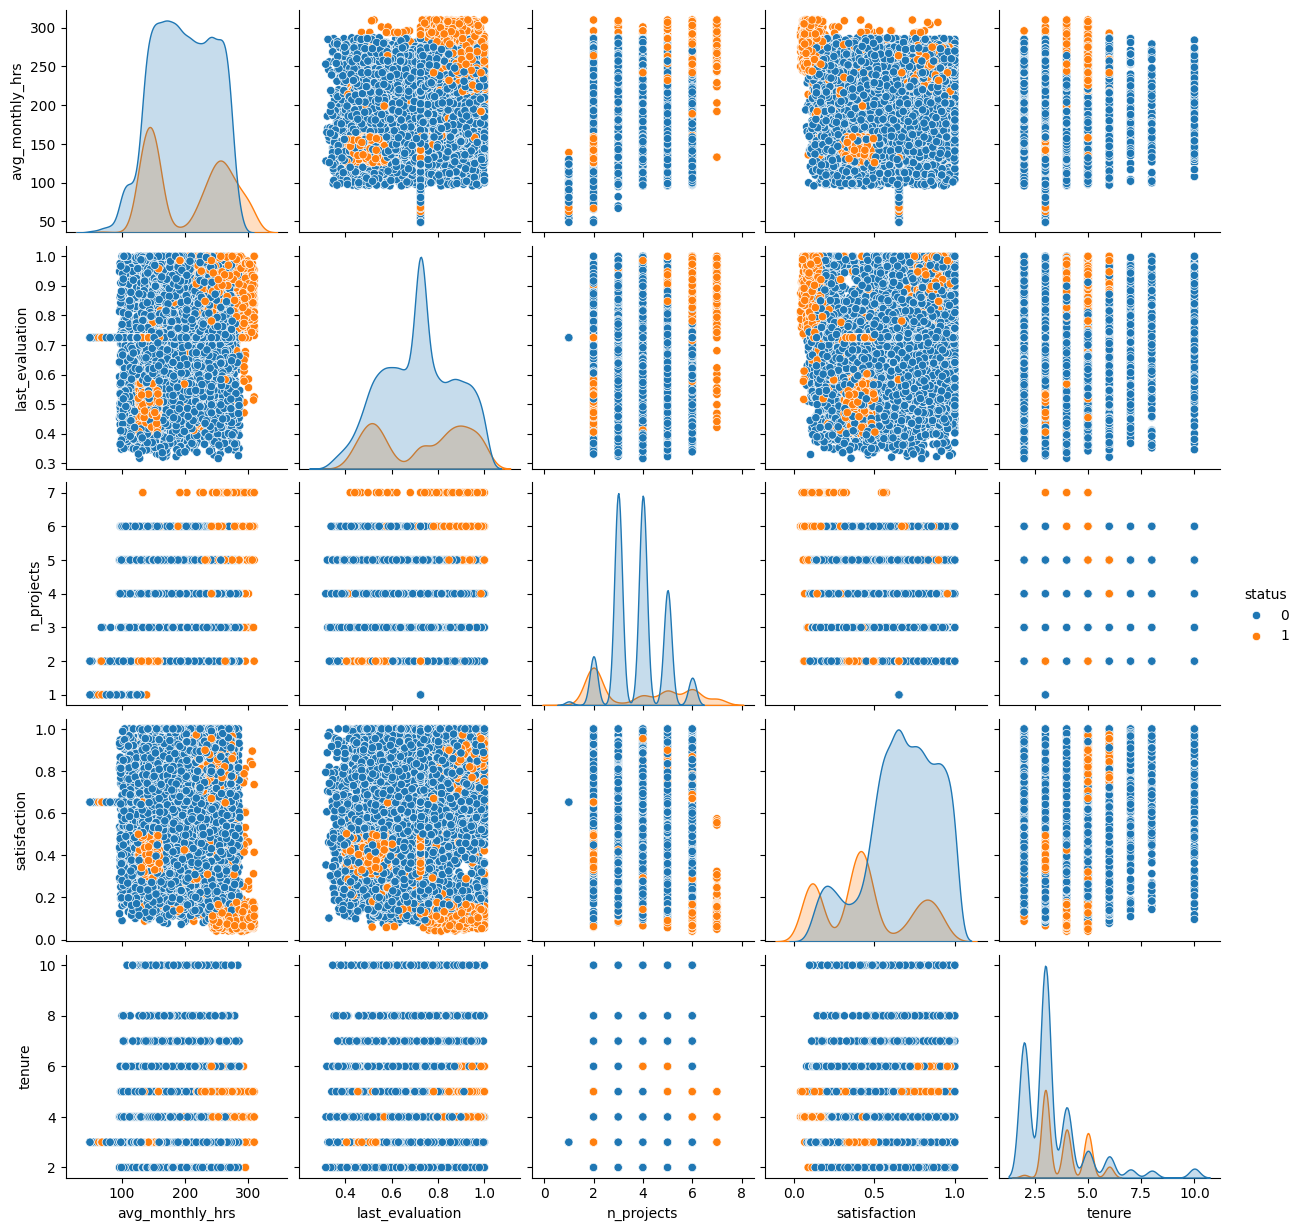

In [315]:
selections = ['avg_monthly_hrs', 'last_evaluation', 'n_projects', 'satisfaction', 'tenure', 'status']

# Plotting
sns.pairplot(data[selections], hue='status')  # status: Employed ya Left
plt.show()